# Тест 2 — влияние числа точек коллокации и условий


In [ ]:
import os, sys
assert os.path.exists('pinn_core.py')
assert os.path.exists('cell_viz_v4.py')
assert os.path.exists('tests_common.py')

import numpy as np
import matplotlib.pyplot as plt
import torch
import pickle
from pathlib import Path

%run -i pinn_core.py
%run -i cell_viz_v4.py
%run -i tests_common.py

print('Device:', 'cuda' if torch.cuda.is_available() else 'cpu')

RESULTS_DIR = Path('results'); RESULTS_DIR.mkdir(exist_ok=True)
PLOTS_DIR   = Path('plots');   PLOTS_DIR.mkdir(exist_ok=True)
RESULTS_PATH = RESULTS_DIR / 'test2_collocation.pkl'

PINN Solver loaded
tests_common.py loaded
Device: cuda


## Конфигурация эксперимента

In [ ]:
N_COLL_GRID = [200, 1000, 3000, 5000, 8000]
N_COND_GRID = [30, 150, 600, 1500]

TRAIN_KWARGS = dict(
    n_epochs_adam=6000,
    lbfgs_max_iter=1500,
    use_lbfgs=True,
    early_stop_patience=300,
    early_stop_rtol=1e-9,
    lr=1e-3,
    sampling='random',
    scheduler_type='cosine',
)


TASKS = [task_hyperbolic(), task_elliptic(), task_parabolic_2d()]

CONFIGS = []
for nc in N_COLL_GRID:
    for nb in N_COND_GRID:
        CONFIGS.append({
            'config_id': f'Nc{nc}_Nbc{nb}',
            'arch_kwargs': {},
            'points_kwargs': {'n_collocation': nc, 'n_condition': nb},
        })

HISTORY_FOR = ['Nc200_Nbc30', 'Nc8000_Nbc30', 'Nc8000_Nbc1500',
               'Nc3000_Nbc150', 'Nc1000_Nbc600']

print(f'{len(N_COLL_GRID)}×{len(N_COND_GRID)} = {len(CONFIGS)} конфигов '
      f'× {len(TASKS)} задач = {len(CONFIGS) * len(TASKS)} прогонов')

5×4 = 20 конфигов × 3 задач = 60 прогонов


## Главный эксперимент

In [4]:
results = run_grid(
    tasks=TASKS,
    configs=CONFIGS,
    train_kwargs=TRAIN_KWARGS,
    save_path=RESULTS_PATH,
    save_history_for=HISTORY_FOR,
    seed=42,
    verbose=True,
)
print(f'\n{len(results)} результатов сохранено в {RESULTS_PATH}')

[1/60] hyperbolic    / Nc200_Nbc30           (elapsed 0.0min, ETA 0.0min)
  rel_l2=1.551e-03  max|Δ|=3.003e-03  time=140.4s  params=37633
[2/60] hyperbolic    / Nc200_Nbc150          (elapsed 2.3min, ETA 138.0min)
  rel_l2=1.513e-03  max|Δ|=2.932e-03  time=138.8s  params=37633
[3/60] hyperbolic    / Nc200_Nbc600          (elapsed 4.7min, ETA 134.9min)
  rel_l2=5.332e-04  max|Δ|=1.002e-03  time=143.9s  params=37633
[4/60] hyperbolic    / Nc200_Nbc1500         (elapsed 7.1min, ETA 134.0min)
  rel_l2=1.500e-03  max|Δ|=2.911e-03  time=147.2s  params=37633
[5/60] hyperbolic    / Nc1000_Nbc30          (elapsed 9.5min, ETA 133.1min)
  rel_l2=9.054e-04  max|Δ|=1.659e-03  time=139.7s  params=37633
[6/60] hyperbolic    / Nc1000_Nbc150         (elapsed 11.8min, ETA 130.2min)
  rel_l2=5.169e-04  max|Δ|=9.054e-04  time=139.6s  params=37633
[7/60] hyperbolic    / Nc1000_Nbc600         (elapsed 14.2min, ETA 127.4min)
  rel_l2=1.334e-03  max|Δ|=2.645e-03  time=140.3s  params=37633
[8/60] hyperbolic   

## Сводка результатов

In [5]:
results = load_results(RESULTS_PATH)
print_summary_table(results, sort_by='rel_l2', top_k=5)

СВОДКА: 60 прогонов

>>> Задача: hyperbolic   (20 OK, 0 FAILED)

  Топ-5 (по rel_l2):
     config_id    rel_l2   abs_max time_s n_params
 Nc8000_Nbc150 2.574e-04 4.611e-04  161.2    37633
Nc1000_Nbc1500 3.511e-04 6.459e-04  142.4    37633
Nc8000_Nbc1500 4.522e-04 1.008e-03  160.9    37633
 Nc3000_Nbc600 4.586e-04 9.687e-04  138.8    37633
 Nc3000_Nbc150 4.984e-04 9.449e-04  139.0    37633

  Хуже всех:
    config_id    rel_l2   abs_max time_s n_params
Nc200_Nbc1500 1.500e-03 2.911e-03  147.2    37633
 Nc200_Nbc150 1.513e-03 2.932e-03  138.8    37633
  Nc200_Nbc30 1.551e-03 3.003e-03  140.4    37633

>>> Задача: elliptic   (19 OK, 1 FAILED)

  Топ-5 (по rel_l2):
     config_id    rel_l2   abs_max time_s n_params
  Nc200_Nbc600 7.160e-04 1.636e-03  179.6    26241
 Nc200_Nbc1500 7.233e-04 1.667e-03  179.3    26241
  Nc200_Nbc150 7.256e-04 1.652e-03  180.5    26241
  Nc3000_Nbc30 8.333e-04 1.664e-03  195.3    26241
Nc1000_Nbc1500 8.448e-04 2.042e-03  192.6    26241

  Хуже всех:
    config

## Главный heatmap: Rel L2 vs (n_coll × n_cond)

C:\VKR\pinn\tests_common.py:599: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


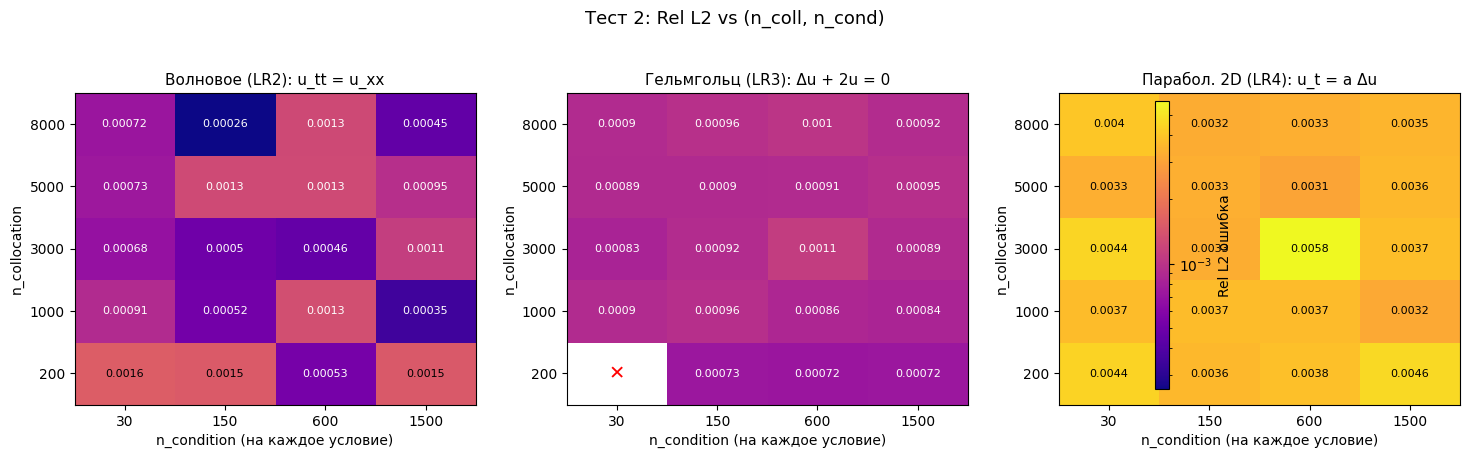

In [6]:
plot_heatmap_3tasks(
    results, TASKS,
    x_grid=N_COND_GRID, y_grid=N_COLL_GRID,
    x_key='points.n_condition', y_key='points.n_collocation',
    value_key='rel_l2', value_label='Rel L2 ошибка',
    x_label='n_condition (на каждое условие)',
    y_label='n_collocation',
    log_color=True, cmap='plasma',
    title='Тест 2: Rel L2 vs (n_coll, n_cond)',
    save_path=PLOTS_DIR / 'test2_heatmap_rel_l2.png',
)

## Линейные графики


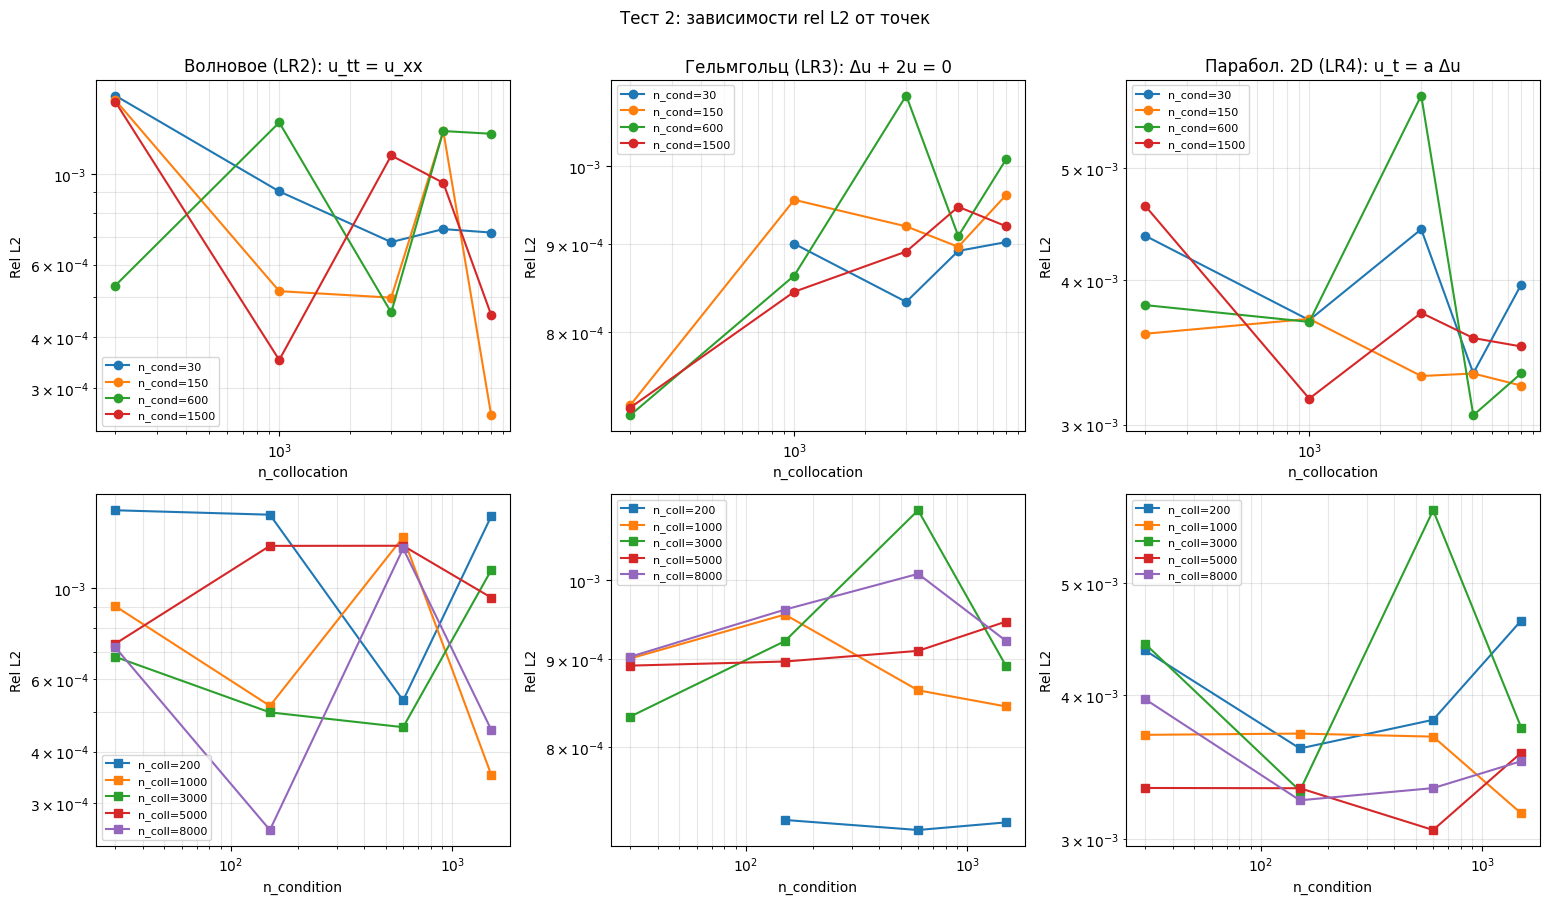

In [ ]:
def plot_lines_two_panels(results, tasks, save_path):
    df = results_to_dataframe(results)
    n = len(tasks)
    fig, axes = plt.subplots(2, n, figsize=(5.2*n, 9), squeeze=False)

    for col, task in enumerate(tasks):
        sub = df[(df['task'] == task['name']) & (~df['failed'])
                 & np.isfinite(df['rel_l2'])]
        ax = axes[0, col]
        for nb in sorted(sub['points.n_condition'].unique()):
            s = sub[sub['points.n_condition'] == nb].sort_values(
                'points.n_collocation')
            ax.plot(s['points.n_collocation'], s['rel_l2'],
                    'o-', lw=1.5, label=f'n_cond={int(nb)}')
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel('n_collocation'); ax.set_ylabel('Rel L2')
        ax.set_title(task['title'])
        ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)

        ax = axes[1, col]
        for nc in sorted(sub['points.n_collocation'].unique()):
            s = sub[sub['points.n_collocation'] == nc].sort_values(
                'points.n_condition')
            ax.plot(s['points.n_condition'], s['rel_l2'],
                    's-', lw=1.5, label=f'n_coll={int(nc)}')
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel('n_condition'); ax.set_ylabel('Rel L2')
        ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)

    plt.suptitle('Тест 2: зависимости rel L2 от точек', y=1.0, fontsize=12)
    plt.tight_layout()
    fig.savefig(save_path, dpi=140, bbox_inches='tight')
    plt.show(); plt.close('all')

plot_lines_two_panels(results, TASKS,
                       PLOTS_DIR / 'test2_lines.png')

## Время обучения

C:\VKR\pinn\tests_common.py:599: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


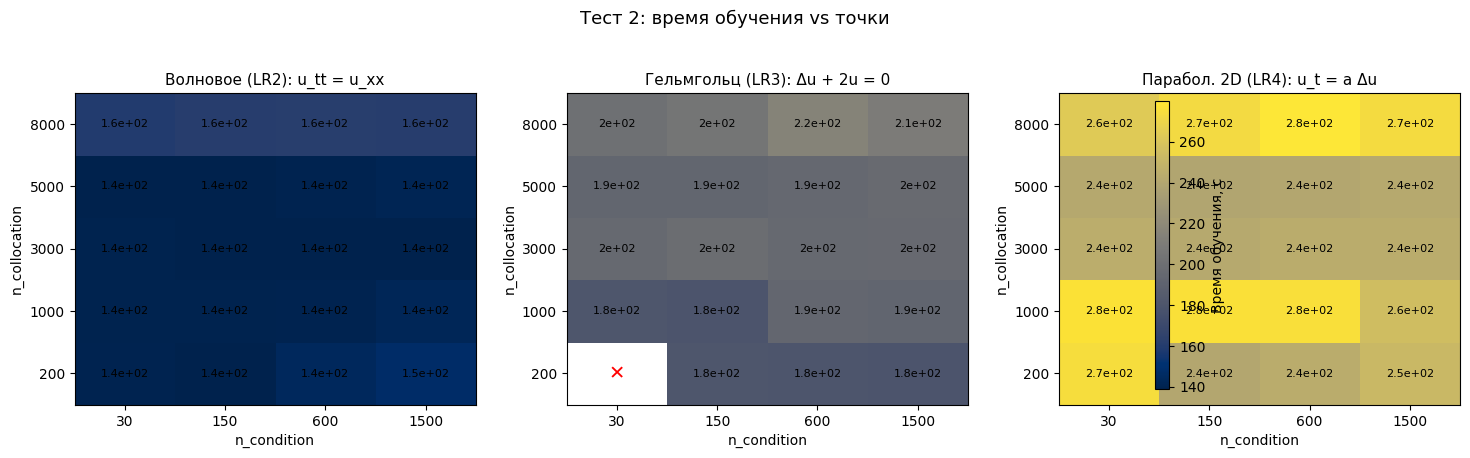

In [8]:
plot_heatmap_3tasks(
    results, TASKS,
    x_grid=N_COND_GRID, y_grid=N_COLL_GRID,
    x_key='points.n_condition', y_key='points.n_collocation',
    value_key='time_s', value_label='Время обучения, с',
    x_label='n_condition', y_label='n_collocation',
    log_color=False, cmap='cividis',
    title='Тест 2: время обучения vs точки',
    save_path=PLOTS_DIR / 'test2_heatmap_time.png',
)

## Decomposition

C:\VKR\pinn\tests_common.py:599: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


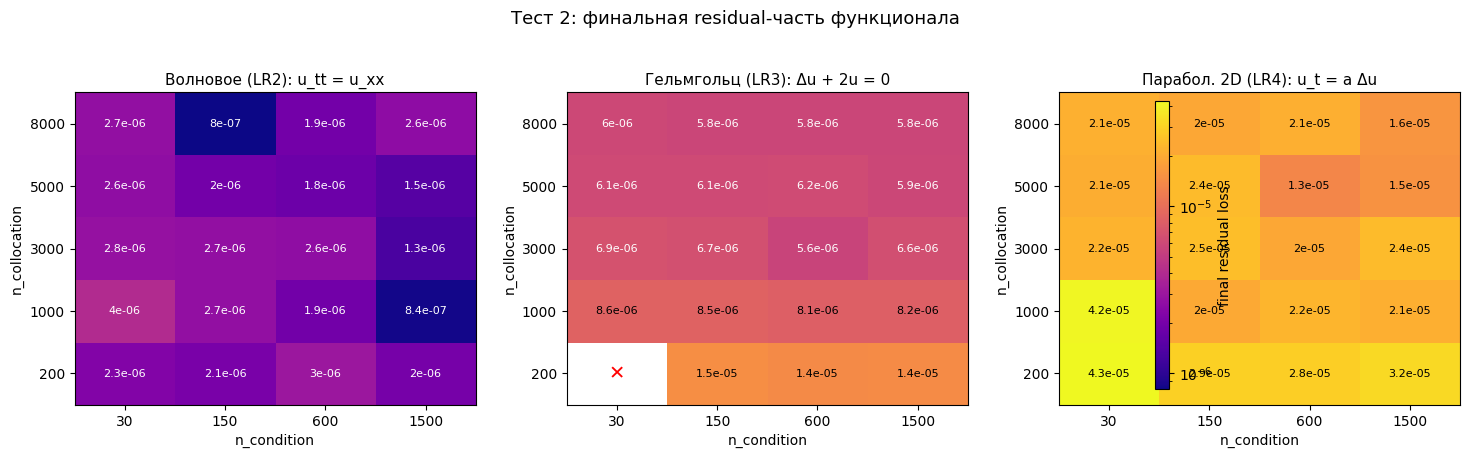

C:\VKR\pinn\tests_common.py:599: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


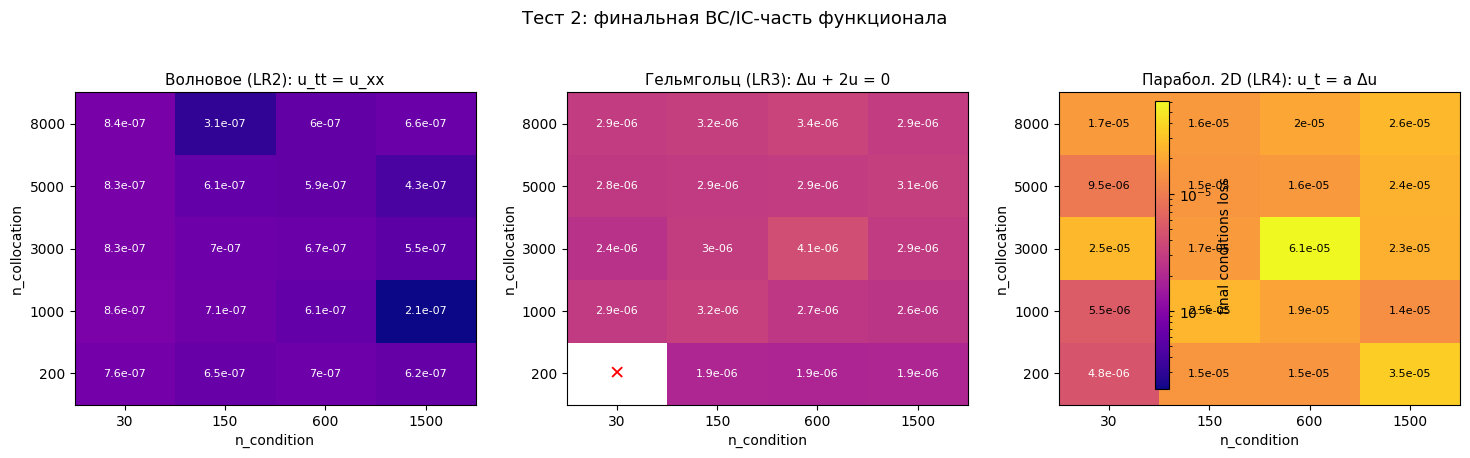

In [9]:
plot_heatmap_3tasks(
    results, TASKS,
    x_grid=N_COND_GRID, y_grid=N_COLL_GRID,
    x_key='points.n_condition', y_key='points.n_collocation',
    value_key='final_residual', value_label='final residual loss',
    x_label='n_condition', y_label='n_collocation',
    log_color=True, cmap='plasma',
    title='Тест 2: финальная residual-часть функционала',
    save_path=PLOTS_DIR / 'test2_heatmap_residual.png',
)
plot_heatmap_3tasks(
    results, TASKS,
    x_grid=N_COND_GRID, y_grid=N_COLL_GRID,
    x_key='points.n_condition', y_key='points.n_collocation',
    value_key='final_conditions', value_label='final conditions loss',
    x_label='n_condition', y_label='n_collocation',
    log_color=True, cmap='plasma',
    title='Тест 2: финальная BC/IC-часть функционала',
    save_path=PLOTS_DIR / 'test2_heatmap_conditions.png',
)

## Кривые training loss

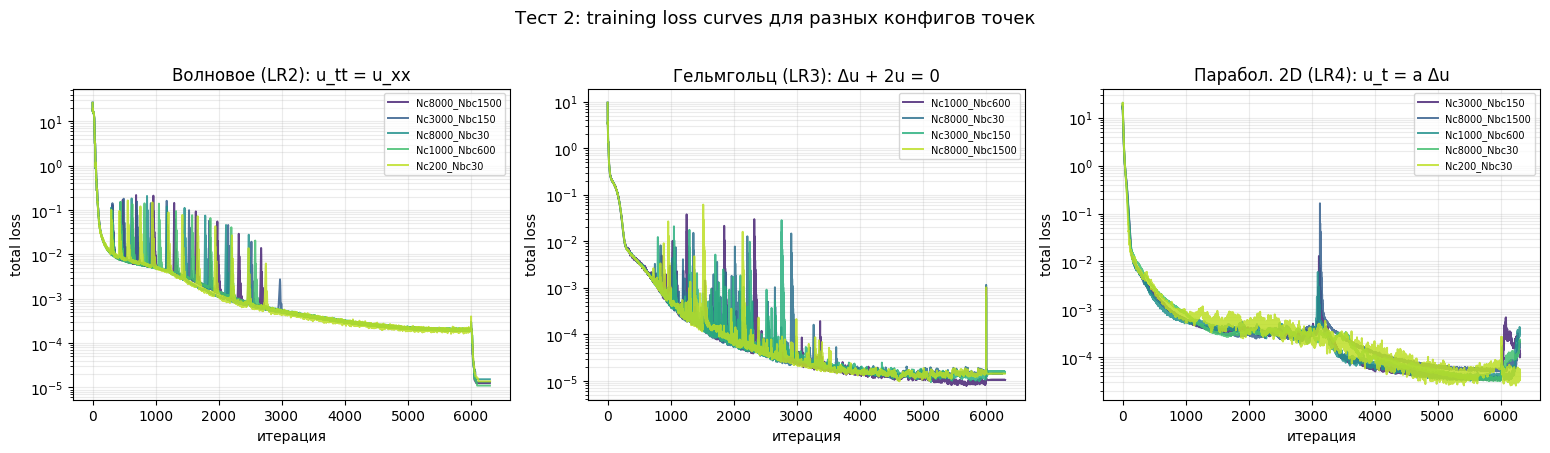

In [10]:
plot_loss_curves_per_task(
    results, TASKS, n_show=5, sort_by='rel_l2',
    title='Тест 2: training loss curves для разных конфигов точек',
    save_path=PLOTS_DIR / 'test2_loss_curves.png',
)

## Результаты

In [12]:
df1 = results_to_dataframe(load_results('results/test1_architecture.pkl'))
df1.to_csv('test1_results.csv', index=False)

df2 = results_to_dataframe(load_results('results/test2_collocation.pkl'))
df2.to_csv('test2_results.csv', index=False)

In [13]:
print_summary_table(load_results('results/test1_architecture.pkl'))
print_summary_table(load_results('results/test2_collocation.pkl'))

СВОДКА: 48 прогонов

>>> Задача: hyperbolic   (16 OK, 0 FAILED)

  Топ-5 (по rel_l2):
config_id    rel_l2   abs_max time_s n_params
   L1_H96 2.259e-04 4.083e-04   88.4      385
   L1_H16 2.639e-04 4.021e-04   93.7       65
   L6_H96 3.435e-04 8.343e-04  177.6    46945
   L4_H96 3.632e-04 5.568e-04  130.5    28321
   L4_H48 4.907e-04 1.120e-03  131.1     7249

  Хуже всех:
config_id    rel_l2   abs_max time_s n_params
   L2_H48 1.960e-03 3.339e-03   98.5     2545
  L4_H144 2.286e-03 3.928e-03  136.3    63217
   L2_H16 5.082e-03       0.0  112.7      337

>>> Задача: elliptic   (16 OK, 0 FAILED)

  Топ-5 (по rel_l2):
config_id    rel_l2   abs_max time_s n_params
   L6_H96 2.033e-04 7.347e-04  220.5    46945
   L2_H96 4.383e-04 6.816e-04  116.0     9697
  L6_H144 7.363e-04 1.650e-03  221.6   104977
   L2_H16 9.058e-04 2.879e-03  114.7      337
   L2_H48 9.696e-04 2.577e-03  115.4     2545

  Хуже всех:
config_id    rel_l2   abs_max time_s n_params
   L1_H16 5.684e-03 7.613e-03  101.9    